<a href="https://colab.research.google.com/github/mohamed0barhoomi/checkpoint_data/blob/main/projet_final_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import ResNet50,EfficientNetB0
from tensorflow.keras import layers,models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input
import os

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/kermany2018")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'kermany2018' dataset.
Path to dataset files: /kaggle/input/kermany2018


In [ ]:
print(os.listdir(path))

['OCT2017 ', 'oct2017']


In [ ]:
data=os.path.join(path, 'OCT2017 ')
print(os.listdir(data))

['val', 'test', 'train']


In [ ]:
modification=ImageDataGenerator(
    #  preprocessing_function=preprocess_input,
    rescale=1/255.0,
    validation_split=0.2,
    # rotation_range=20,
    # zoom_range=0.2,
    # width_shift_range=0.3,
    # height_shift_range=0.15,
    # horizontal_flip=True
    )

In [ ]:

train=modification.flow_from_directory(
    os.path.join(data,'train'),
    batch_size=32,
    target_size=(224,224),
    class_mode="categorical",
    subset="training"

)
val=modification.flow_from_directory(
    os.path.join(data,'train'),
    batch_size=32,
    target_size=(224,224),
    class_mode="categorical",
    subset="validation"
)

Found 66788 images belonging to 4 classes.
Found 16696 images belonging to 4 classes.


In [ ]:
print(train.samples)
print(val.samples)
x, y = next(train)
print(x.shape, y.shape)
x, y = next(val)
print(x.shape, y.shape)

66788
16696
(32, 224, 224, 3) (32, 4)
(32, 224, 224, 3) (32, 4)


In [ ]:
test=ImageDataGenerator(rescale=1/255.0).flow_from_directory(
    os.path.join(data,"test"),
    batch_size=32,
    target_size=(224,224),
    class_mode="categorical"
)

Found 968 images belonging to 4 classes.


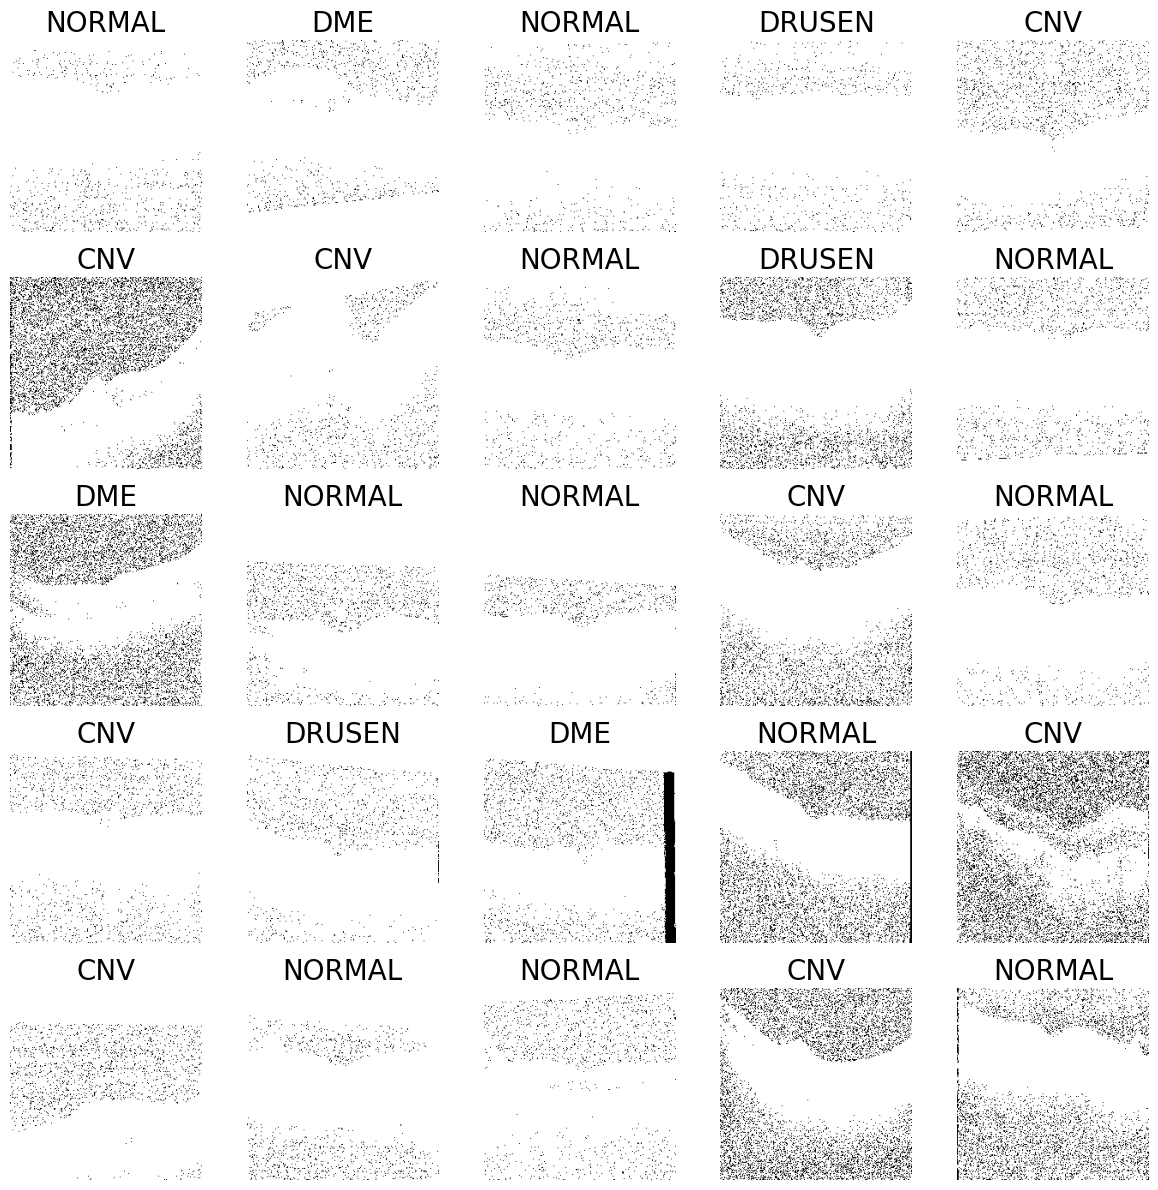

In [ ]:
images, labels = next(train)

plt.figure(figsize=(12,12))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(images[i]*255)
    class_index = labels[i].argmax()
    class_name = list(train.class_indices.keys())[class_index]
    plt.title(class_name, fontsize=20)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
base_model=ResNet50(weights="imagenet",include_top=False,input_shape=(224,224,3))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


In [ ]:
for lay in base_model.layers:
  lay.trainable=False

In [ ]:
model=models.Sequential(
  [  base_model,
    layers.Flatten(),
    layers.BatchNormalization(),
    layers.Dense(256,activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(4,activation="softmax")]

)

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history=model.fit(train,epochs=13,validation_data=val)

Epoch 1/13
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 691s 331ms/step - accuracy: 0.6758 - loss: 0.8616 - val_accuracy: 0.7136 - val_loss: 0.7584
Epoch 2/13
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 330s 158ms/step - accuracy: 0.7103 - loss: 0.7596 - val_accuracy: 0.7566 - val_loss: 0.6867
Epoch 3/13
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 346s 166ms/step - accuracy: 0.7304 - loss: 0.7124 - val_accuracy: 0.7665 - val_loss: 0.6553
Epoch 4/13
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 344s 165ms/step - accuracy: 0.7440 - loss: 0.6821 - val_accuracy: 0.7638 - val_loss: 0.6739
Epoch 5/13
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 342s 164ms/step - accuracy: 0.7490 - loss: 0.6625 - val_accuracy: 0.7801 - val_loss: 0.6368
Epoch 6/13
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 351s 168ms/step - accuracy: 0.7573 - loss: 0.6431 - val_accuracy: 0.7784 - val_loss: 0.6258
Epoch 7/13
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 346s 166ms/step - accuracy: 0.7597 - loss: 0.6337 - val_accuracy: 0.7736 - val_loss: 0.6262
Epoch 8/13
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 353s 169ms/step - ac

In [ ]:
acc,loss=model.evaluate(val)
print("first acc : ",acc)
print("first loss : ",loss)

522/522 ━━━━━━━━━━━━━━━━━━━━ 67s 128ms/step - accuracy: 0.7919 - loss: 0.6093
first acc :  0.6093418598175049
first loss :  0.7919262051582336


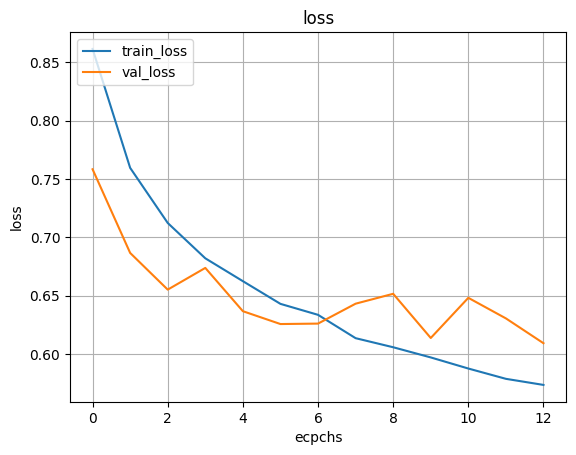

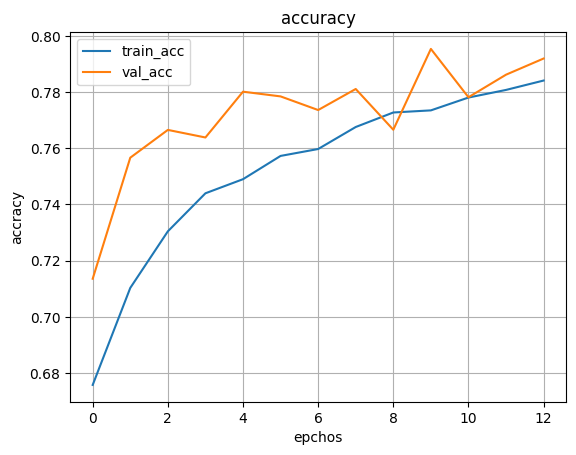

In [ ]:
plt.figure()
plt.plot(history.history["loss"],label="train_loss")
plt.plot(history.history["val_loss"],label="val_loss")
plt.legend(loc='upper left')
plt.title("loss")
plt.xlabel("ecpchs")
plt.ylabel("loss")
plt.grid()
plt.show()
plt.figure()
plt.plot(history.history["accuracy"],label="train_acc")
plt.plot(history.history["val_accuracy"],label="val_acc")
plt.legend(loc="upper left")
plt.title("accuracy")
plt.xlabel("epchos")
plt.ylabel("accracy")
plt.grid()
plt.show()

In [ ]:
for lay in model.layers:
  lay.trainable=True

In [ ]:
model.compile(
    optimizer="Adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_2=model.fit(train,epochs=5,validation_data=val)

Epoch 1/5
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 354s 164ms/step - accuracy: 0.7884 - loss: 0.5679 - val_accuracy: 0.7952 - val_loss: 0.6483
Epoch 2/5
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 353s 169ms/step - accuracy: 0.7882 - loss: 0.5641 - val_accuracy: 0.7894 - val_loss: 0.6366
Epoch 3/5
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 350s 168ms/step - accuracy: 0.7900 - loss: 0.5560 - val_accuracy: 0.7924 - val_loss: 0.6801
Epoch 4/5
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 334s 160ms/step - accuracy: 0.7930 - loss: 0.5466 - val_accuracy: 0.7895 - val_loss: 0.6619
Epoch 5/5
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 338s 162ms/step - accuracy: 0.7942 - loss: 0.5467 - val_accuracy: 0.7911 - val_loss: 0.6434


In [ ]:
acc2,loss2 =model.evaluate(val)
print("second acc : ",acc)
print("second loss : ",loss)

522/522 ━━━━━━━━━━━━━━━━━━━━ 66s 126ms/step - accuracy: 0.7911 - loss: 0.6434
second acc :  0.6093418598175049
second loss :  0.7919262051582336


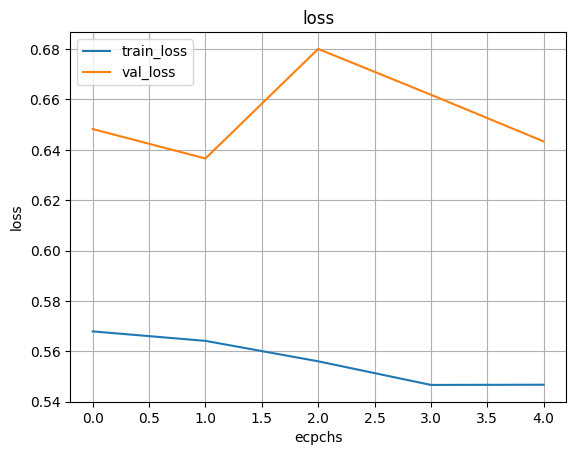

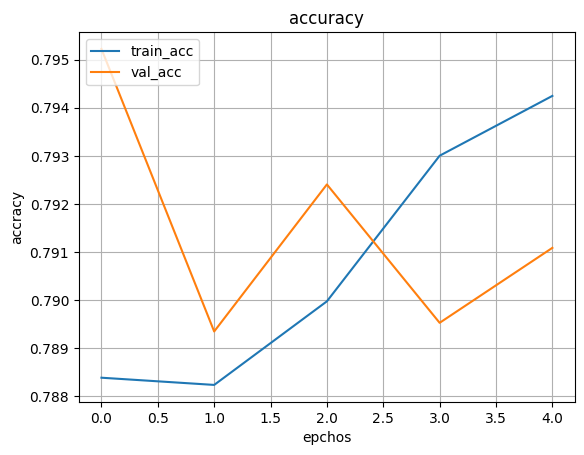

In [ ]:
plt.figure()
plt.plot(history_2.history["loss"],label="train_loss")
plt.plot(history_2.history["val_loss"],label="val_loss")
plt.legend(loc='upper left')
plt.title("loss")
plt.xlabel("ecpchs")
plt.ylabel("loss")
plt.grid()
plt.show()
plt.figure()
plt.plot(history_2.history["accuracy"],label="train_acc")
plt.plot(history_2.history["val_accuracy"],label="val_acc")
plt.legend(loc="upper left")
plt.title("accuracy")
plt.xlabel("epchos")
plt.ylabel("accracy")
plt.grid()
plt.show()

In [ ]:
test.reset()
pred=model.predict(test)
pred=np.argmax(pred,axis=1)
print(pred)

31/31 ━━━━━━━━━━━━━━━━━━━━ 17s 421ms/step


In [ ]:
images, labels = next(test)
class_names = list(test.class_indices.keys())
print(labels)

TypeError: only integer scalar arrays can be converted to a scalar index

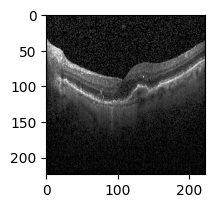

In [ ]:


plt.figure(figsize=(12,12))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(images[i])
    true_index = labels[i]
    pred_index = pred[i]
    plt.title(
        f"True: {class_names[true_index]}\nPred: {class_names[pred_index]}",
        fontsize=8
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(train,test))